# Drowsy Image Classifier Training v1

This notebook trains a binary image classifier on the following dataset structure:

```text
data/
  train/
    DROWSY/
    NATURAL/
  test/
    DROWSY/
    NATURAL/
```

It uses a pretrained **ResNet18** in PyTorch, splits part of `train/` into a validation set, evaluates on `test/`, and saves the best model.

Recommended runtime: **Colab GPU**.

## 1. Install / import packages

If you are running in Colab, the standard PyTorch stack is usually preinstalled. The next cell only installs a few extras if needed.

In [ ]:
# Uncomment if needed in a fresh environment
# !pip install torch torchvision scikit-learn matplotlib seaborn


In [1]:
import os
import copy
import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms, models

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

print('torch version:', torch.__version__)
print('cuda available:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('gpu:', torch.cuda.get_device_name(0))


torch version: 2.10.0+cu128
cuda available: True
gpu: NVIDIA A100-SXM4-80GB


## 2. Reproducibility

Set seeds for more repeatable training runs.

In [2]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False


## 3. Mount Google Drive or set local path

Use one of the two options below.

- **Option A**: Mount Google Drive and point `DATA_DIR` to your dataset.
- **Option B**: If you already uploaded/extracted data into the notebook runtime, set `DATA_DIR` directly.

In [4]:
# Option A: Google Drive
from google.colab import drive
drive.mount('/content/drive')

DATA_DIR = '/content/drive/MyDrive/data'

# Option B: runtime/local path
# DATA_DIR = '/content/data'  # <-- change this

TRAIN_DIR = os.path.join(DATA_DIR, 'train')
TEST_DIR = os.path.join(DATA_DIR, 'test')

print('TRAIN_DIR:', TRAIN_DIR)
print('TEST_DIR :', TEST_DIR)
print('train exists:', os.path.exists(TRAIN_DIR))
print('test exists :', os.path.exists(TEST_DIR))


Mounted at /content/drive
TRAIN_DIR: /content/drive/MyDrive/data/train
TEST_DIR : /content/drive/MyDrive/data/test
train exists: True
test exists : True


## 4. Define transforms

We use standard ImageNet normalization because ResNet18 is pretrained on ImageNet.

In [5]:
IMG_SIZE = 224

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])


## 5. Load datasets and split train/val

Since your current structure has `train/` and `test/` but no separate `val/`, we split a portion of `train/` into validation.

In [6]:
full_train_dataset = datasets.ImageFolder(TRAIN_DIR, transform=train_transform)
test_dataset = datasets.ImageFolder(TEST_DIR, transform=eval_transform)

print('class_to_idx:', full_train_dataset.class_to_idx)
idx_to_class = {v: k for k, v in full_train_dataset.class_to_idx.items()}
print('idx_to_class:', idx_to_class)

val_ratio = 0.2
val_size = int(len(full_train_dataset) * val_ratio)
train_size = len(full_train_dataset) - val_size

train_subset, val_subset = random_split(
    full_train_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED)
)

# Important: random_split keeps the same underlying dataset object.
# We want different transforms for train and val, so we rebuild them.
train_dataset = copy.deepcopy(train_subset)
val_dataset = copy.deepcopy(val_subset)

train_dataset.dataset = datasets.ImageFolder(TRAIN_DIR, transform=train_transform)
val_dataset.dataset = datasets.ImageFolder(TRAIN_DIR, transform=eval_transform)

print(f'Train size: {len(train_dataset)}')
print(f'Val size  : {len(val_dataset)}')
print(f'Test size : {len(test_dataset)}')


class_to_idx: {'DROWSY': 0, 'NATURAL': 1}
idx_to_class: {0: 'DROWSY', 1: 'NATURAL'}
Train size: 4688
Val size  : 1171
Test size : 1483


## 6. Create dataloaders

In [7]:
BATCH_SIZE = 32
NUM_WORKERS = 2

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)


## 7. Visualize a few training images

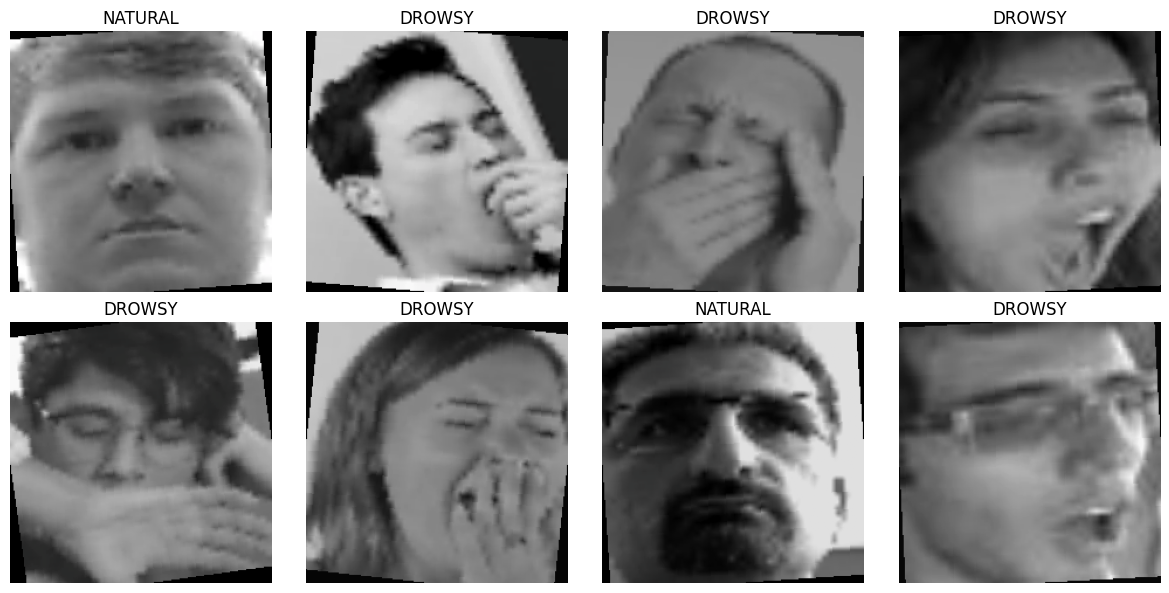

In [8]:
def denormalize(img_tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    return img_tensor * std + mean

images, labels = next(iter(train_loader))
plt.figure(figsize=(12, 6))
for i in range(min(8, len(images))):
    plt.subplot(2, 4, i + 1)
    img = denormalize(images[i]).permute(1, 2, 0).numpy()
    img = np.clip(img, 0, 1)
    plt.imshow(img)
    plt.title(idx_to_class[labels[i].item()])
    plt.axis('off')
plt.tight_layout()
plt.show()


## 8. Build model

We start with a pretrained ResNet18 and replace the final classification layer for binary classification.

In [9]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

weights = models.ResNet18_Weights.DEFAULT
model = models.resnet18(weights=weights)

# Replace final fully connected layer
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 2)

model = model.to(device)
print(model)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 241MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

## 9. Loss, optimizer, scheduler

In [10]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)


## 10. Training and evaluation helpers

In [11]:
def run_one_epoch(model, loader, criterion, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    running_loss = 0.0
    running_corrects = 0
    total = 0

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        with torch.set_grad_enabled(is_train):
            outputs = model(images)
            loss = criterion(outputs, labels)
            _, preds = torch.max(outputs, 1)

            if is_train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

        running_loss += loss.item() * images.size(0)
        running_corrects += torch.sum(preds == labels).item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = running_corrects / total
    return epoch_loss, epoch_acc


def predict_loader(model, loader):
    model.eval()
    all_labels = []
    all_preds = []
    all_probs = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device, non_blocking=True)
            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)
            preds = torch.argmax(probs, dim=1)

            all_labels.extend(labels.numpy().tolist())
            all_preds.extend(preds.cpu().numpy().tolist())
            all_probs.extend(probs.cpu().numpy().tolist())

    return np.array(all_labels), np.array(all_preds), np.array(all_probs)


## 11. Train model

In [13]:
EPOCHS = 10
best_val_acc = 0.0
best_model_path = '/content/drive/MyDrive/best_resnet18_drowsy_classifier.pth'

history = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': [],
}

for epoch in range(EPOCHS):
    train_loss, train_acc = run_one_epoch(model, train_loader, criterion, optimizer)
    val_loss, val_acc = run_one_epoch(model, val_loader, criterion, optimizer=None)
    scheduler.step(val_loss)

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    print(f'Epoch [{epoch+1}/{EPOCHS}] | '
          f'Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | '
          f'Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}')

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), best_model_path)
        print(f'  -> Saved best model to {best_model_path}')

print('Best validation accuracy:', best_val_acc)


Epoch [1/10] | Train Loss: 0.0316, Train Acc: 0.9900 | Val Loss: 0.0151, Val Acc: 0.9923
  -> Saved best model to /content/drive/MyDrive/best_resnet18_drowsy_classifier.pth
Epoch [2/10] | Train Loss: 0.0295, Train Acc: 0.9904 | Val Loss: 0.0231, Val Acc: 0.9915
Epoch [3/10] | Train Loss: 0.0160, Train Acc: 0.9947 | Val Loss: 0.0139, Val Acc: 0.9949
  -> Saved best model to /content/drive/MyDrive/best_resnet18_drowsy_classifier.pth
Epoch [4/10] | Train Loss: 0.0090, Train Acc: 0.9970 | Val Loss: 0.0164, Val Acc: 0.9932
Epoch [5/10] | Train Loss: 0.0118, Train Acc: 0.9964 | Val Loss: 0.0113, Val Acc: 0.9949
Epoch [6/10] | Train Loss: 0.0121, Train Acc: 0.9959 | Val Loss: 0.0206, Val Acc: 0.9932
Epoch [7/10] | Train Loss: 0.0152, Train Acc: 0.9957 | Val Loss: 0.0135, Val Acc: 0.9957
  -> Saved best model to /content/drive/MyDrive/best_resnet18_drowsy_classifier.pth
Epoch [8/10] | Train Loss: 0.0048, Train Acc: 0.9985 | Val Loss: 0.0103, Val Acc: 0.9966
  -> Saved best model to /content/dr

## 12. Plot training curves

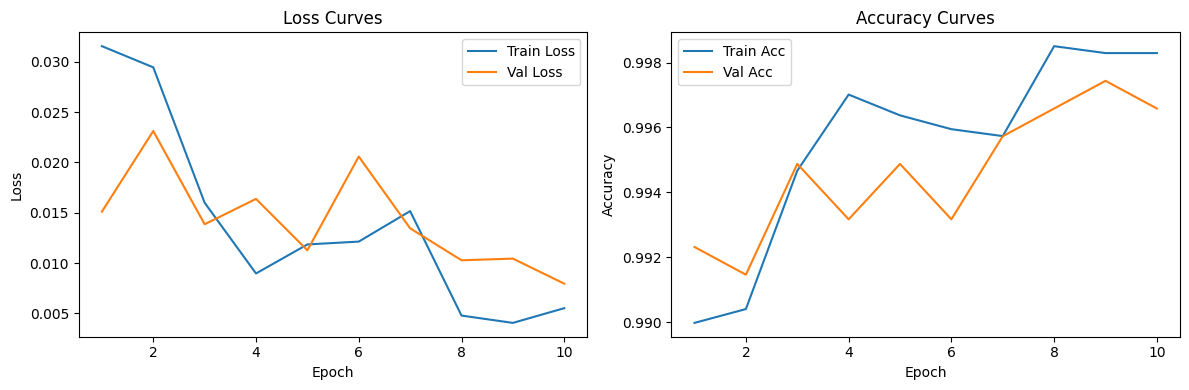

In [14]:
epochs_range = range(1, EPOCHS + 1)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, history['train_loss'], label='Train Loss')
plt.plot(epochs_range, history['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss Curves')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, history['train_acc'], label='Train Acc')
plt.plot(epochs_range, history['val_acc'], label='Val Acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy Curves')
plt.legend()

plt.tight_layout()
plt.show()


## 13. Evaluate best model on test set

In [15]:
best_model = models.resnet18(weights=None)
best_model.fc = nn.Linear(best_model.fc.in_features, 2)
best_model.load_state_dict(torch.load(best_model_path, map_location=device))
best_model = best_model.to(device)

y_true, y_pred, y_prob = predict_loader(best_model, test_loader)
test_acc = (y_true == y_pred).mean()
print(f'Test Accuracy: {test_acc:.4f}')

print('\nClassification Report:')
print(classification_report(y_true, y_pred, target_names=[idx_to_class[i] for i in range(len(idx_to_class))]))


Test Accuracy: 0.9993

Classification Report:
              precision    recall  f1-score   support

      DROWSY       1.00      1.00      1.00       757
     NATURAL       1.00      1.00      1.00       726

    accuracy                           1.00      1483
   macro avg       1.00      1.00      1.00      1483
weighted avg       1.00      1.00      1.00      1483



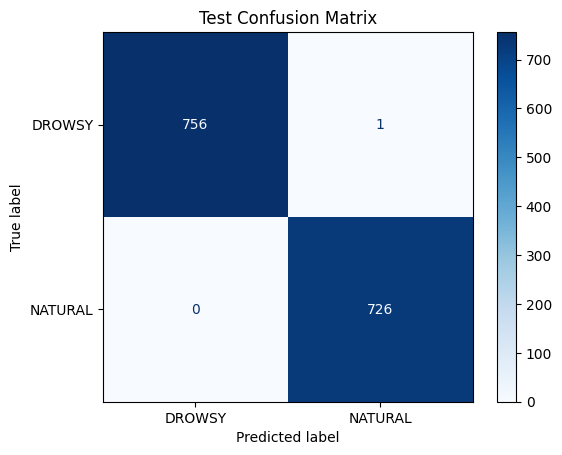

In [16]:
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[idx_to_class[i] for i in range(len(idx_to_class))])
disp.plot(cmap='Blues', values_format='d')
plt.title('Test Confusion Matrix')
plt.show()


## 14. Inspect sample predictions

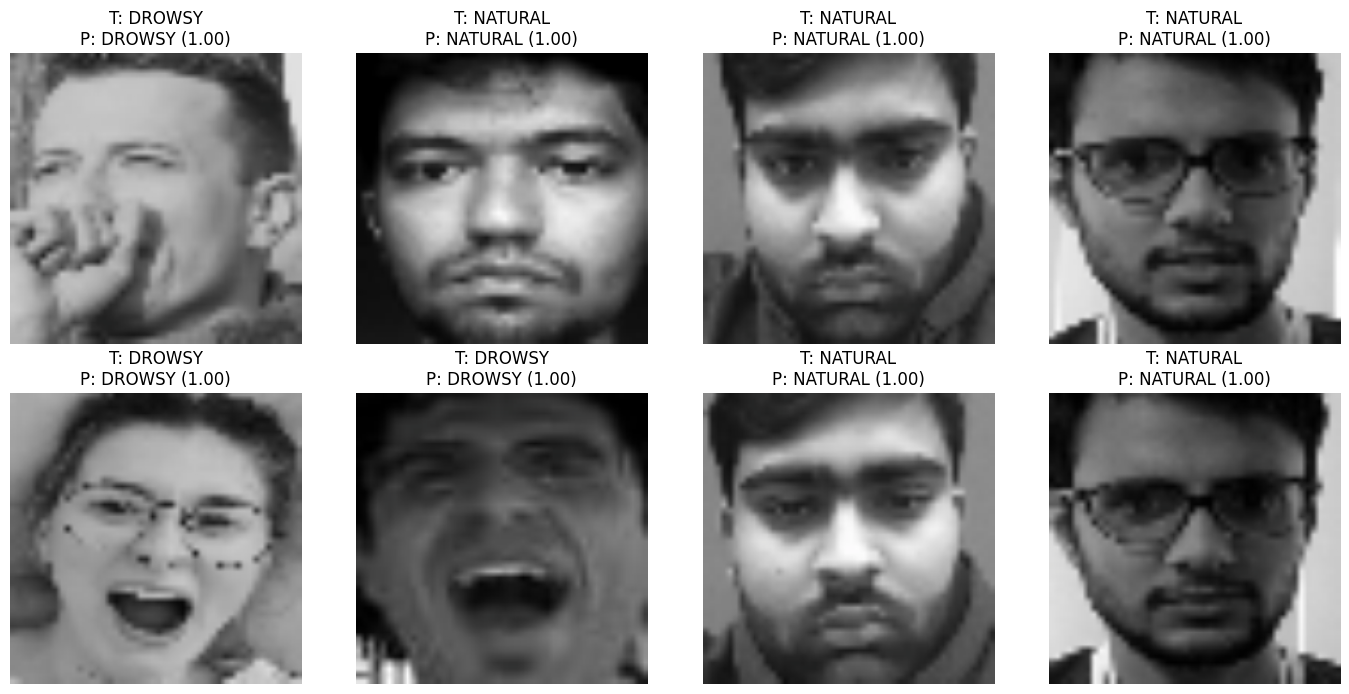

In [17]:
inv_test_dataset = datasets.ImageFolder(TEST_DIR, transform=eval_transform)

sample_loader = DataLoader(inv_test_dataset, batch_size=8, shuffle=True)
images, labels = next(iter(sample_loader))

best_model.eval()
with torch.no_grad():
    outputs = best_model(images.to(device))
    probs = torch.softmax(outputs, dim=1)
    preds = torch.argmax(probs, dim=1).cpu()

plt.figure(figsize=(14, 7))
for i in range(min(8, len(images))):
    plt.subplot(2, 4, i + 1)
    img = denormalize(images[i]).permute(1, 2, 0).numpy()
    img = np.clip(img, 0, 1)
    plt.imshow(img)
    true_label = idx_to_class[labels[i].item()]
    pred_label = idx_to_class[preds[i].item()]
    pred_conf = probs[i, preds[i]].item()
    plt.title(f'T: {true_label}\nP: {pred_label} ({pred_conf:.2f})')
    plt.axis('off')
plt.tight_layout()
plt.show()


## 15. Save useful metadata

This is helpful later when you run inference on video frames.

In [18]:
metadata = {
    'class_to_idx': full_train_dataset.class_to_idx,
    'idx_to_class': idx_to_class,
    'img_size': IMG_SIZE,
    'best_model_path': best_model_path,
}

print(metadata)


{'class_to_idx': {'DROWSY': 0, 'NATURAL': 1}, 'idx_to_class': {0: 'DROWSY', 1: 'NATURAL'}, 'img_size': 224, 'best_model_path': '/content/drive/MyDrive/best_resnet18_drowsy_classifier.pth'}


## 16. Next step

Once this notebook is training and evaluating correctly, the next stage is:

1. Load the saved best model.
2. Read a real video.
3. Extract one frame every 0.5 seconds (or 1 second).
4. Run the model on each frame.
5. Collect the `DROWSY` probability into a time series.
6. Use that sequence in your fatigue score / recommendation pipeline.
